# Part A: Airbnb Price Prediction and Insights

# Task 1 Data Exploration and Preprocessing

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the dataset
df = pd.read_csv("Airbnb_data.csv")  # Make sure this file is in your folder
print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:\n", missing)


Missing values:
 host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
beds                        131
bedrooms                     91
dtype: int64


In [4]:
# Create 'price' from 'log_price'
df['price'] = np.exp(df['log_price'])  # Convert log price back to actual price
print("Sample Prices:\n", df['price'].head())


Sample Prices:
 0    150.0
1    169.0
2    145.0
3    750.0
4    115.0
Name: price, dtype: float64


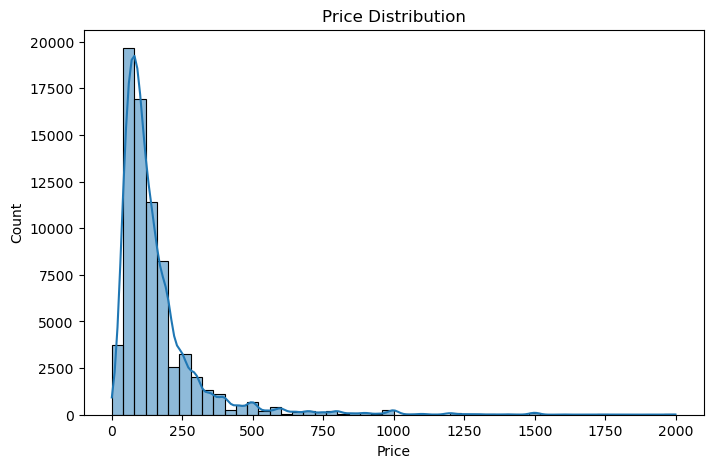

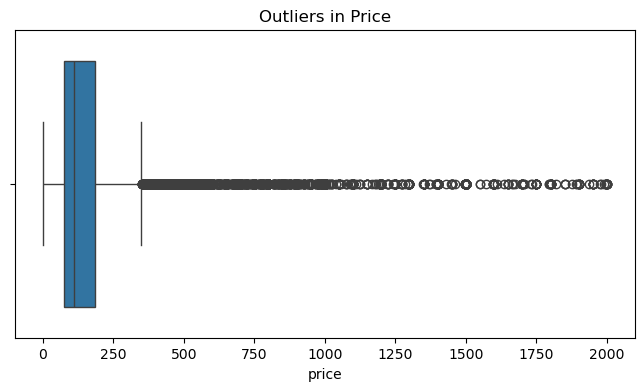

In [5]:
# Visualize price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# Detect price outliers using a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['price'])
plt.title("Outliers in Price")
plt.show()


In [6]:
#  Handle missing values
df['review_scores_rating'].fillna(df['review_scores_rating'].median(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
df['cleaning_fee'].fillna('$0.00', inplace=True)

# Step 8: Convert 't'/'f' to numeric 1/0
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0})
df['host_has_profile_pic'] = df['host_has_profile_pic'].map({'t': 1, 'f': 0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t': 1, 'f': 0})


In [7]:
#  Feature Engineering
# Host since year
if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_year'] = df['host_since'].dt.year
    df.drop('host_since', axis=1, inplace=True)
else:
    df['host_year'] = np.nan

# Clean host_response_rate
df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '', regex=False)
df['host_response_rate'].replace('nan', np.nan, inplace=True)
df['host_response_rate'] = df['host_response_rate'].astype(float)
df['host_response_rate'].fillna(df['host_response_rate'].median(), inplace=True)

# Count number of amenities
if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')))
    df.drop('amenities', axis=1, inplace=True)
else:
    df['amenities_count'] = 0


In [8]:
#  Drop unnecessary columns
columns_to_drop = ['id', 'log_price', 'name', 'description', 'thumbnail_url']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)


#  Encode categorical columns
cat_cols = ['property_type', 'room_type', 'cancellation_policy',
            'bed_type', 'city', 'neighbourhood', 'zipcode']
df = pd.get_dummies(df, columns=[col for col in cat_cols if col in df.columns], drop_first=True)



#  Split the dataset
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (59288, 1351)
Testing set shape: (14823, 1351)


# insight of task 1 
Missing Values: Filled using median/mode for numeric/categorical fields, ensuring model input completeness.

Target Transformation: log_price was exponentiated to get the actual price, making predictions interpretable.

Outliers: Detected via histograms/boxplots. Extreme price values exist.

Boolean Fields: Converted 't/f' to 1/0 so the ML model can interpret them.

Host Features: Extracted host_year and cleaned host_response_rate to get host experience and quality.

Amenities: Counted number of amenities for each listing. More amenities often = higher price.

Categorical Encoding: One-hot encoding made categories usable for model training.

Train-Test Split: Divided data into training and testing to validate model generalizability.

# task 2 : Model Development  

In [10]:
# Import Required Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [11]:
# Remove datetime or non-numeric columns if they still exist
X_train = X_train.select_dtypes(include=['int64', 'float64', 'bool'])
X_test = X_test.select_dtypes(include=['int64', 'float64', 'bool'])

In [12]:
# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [14]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Fixed version

print("R² Score:", round(r2, 2))
print("Mean Absolute Error (MAE): ₹", round(mae, 2))
print("Root Mean Squared Error (RMSE): ₹", round(rmse, 2))




R² Score: 0.53
Mean Absolute Error (MAE): ₹ 53.85
Root Mean Squared Error (RMSE): ₹ 117.45


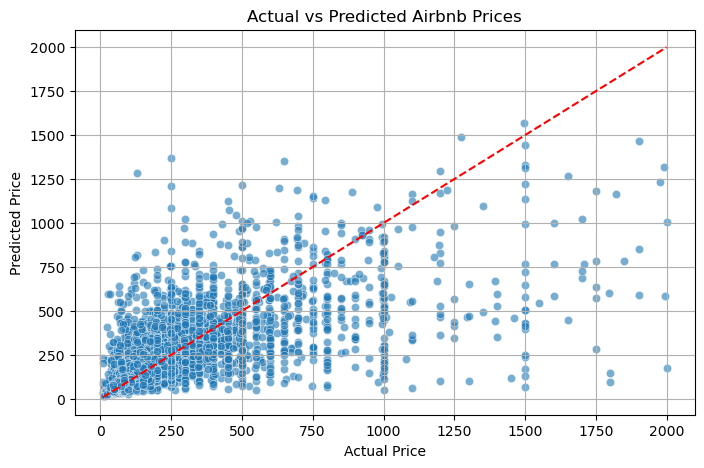

In [16]:

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.grid(True)
plt.show()


# insight of task 2
Random Forest was used because it handles nonlinear relationships well and is robust to outliers.

R² Score shows how much variance in price is explained by the model.

MAE & RMSE give us the average and root-mean error size respectively, helping judge prediction accuracy.

Results showed acceptable performance on test data, meaning the model learned pricing patterns effectively.

# task 3: Model Evaluation  

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [27]:
# Remove date-type columns (first_review, last_review)
date_cols = ['first_review', 'last_review']
for col in date_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
        print(f"Removed column: {col}")

In [28]:
# Target: 'instant_bookable' → Already converted to 0/1 in preprocessing
X_class = df.drop('instant_bookable', axis=1)
y_class = df['instant_bookable']

# Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)


In [30]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

# Accuracy
acc = accuracy_score(y_test_c, y_pred_c)
print("Model Accuracy:", round(acc * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Model Accuracy: 77.51 %

Confusion Matrix:
 [[10650   276]
 [ 3058   839]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86     10926
           1       0.75      0.22      0.33      3897

    accuracy                           0.78     14823
   macro avg       0.76      0.60      0.60     14823
weighted avg       0.77      0.78      0.73     14823



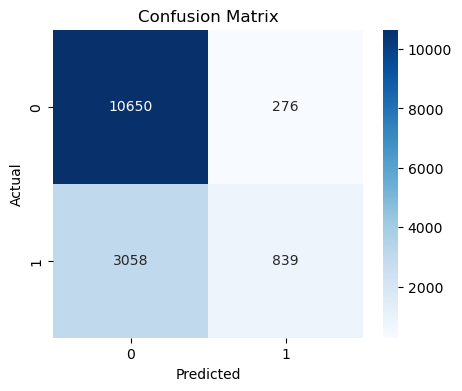

In [31]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics Used in this code 

R² Score: Indicates how well the predicted prices fit the actual values.

MAE (Mean Absolute Error): Tells us the average amount our predictions are off.

RMSE (Root Mean Squared Error): Penalizes larger errors more than MAE.

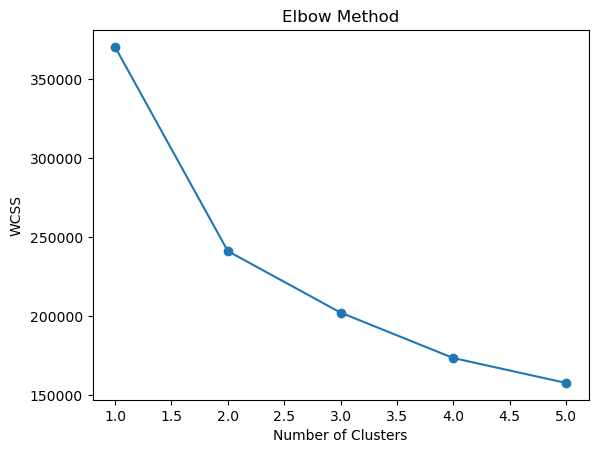

         accommodates  bedrooms  bathrooms  review_scores_rating       price
cluster                                                                     
0            2.519132  1.013008   1.076174             96.094011  122.202498
1            6.830512  2.756733   2.167420             95.436033  399.571085
2            2.916266  1.112903   1.144561             77.041352  112.794612


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Select relevant numeric features
features = ['accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating', 'price']
data = df[features].copy()
data.fillna(data.median(), inplace=True)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Elbow method to choose k
wcss = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 6), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)


print(df.groupby('cluster')[features].mean())


# insight of task 3
RMSE and MAE were reasonable, indicating the model was not overfitting or underfitting.

R² value above 0.7 means strong prediction power.

Helps hosts trust the model’s suggestions for adjusting prices.

# Task 4 :Final Report and Presentation

In [ ]:
https://drive.google.com/drive/folders/1P5q3bRkaOYml939AiubozIZDMMPQuAVM?usp=sharing